# DeepDTA: Deep Drug–Target Binding Affinity Prediction — Reproduction (PyTorch)

Paper: [Öztürk et al., *Bioinformatics* 2018](https://academic.oup.com/bioinformatics/article/34/17/i821/5093245)  
Original repo: <https://github.com/hkmztrk/DeepDTA> (TF1 + old `keras`; this notebook re-implements it in PyTorch).

**Idea**: encode the drug SMILES string and the protein amino-acid sequence with two parallel 1-D CNNs, concatenate the two representations, push through a small MLP, and regress the binding affinity (pKd or KIBA score).

![DeepDTA architecture](https://github.com/hkmztrk/DeepDTA/blob/master/docs/figures/deepdta.PNG?raw=true)




---
## 0. Environment & data download


In [1]:
# Clone the upstream repo if we don't already have the data.
import os, subprocess
if not os.path.isdir('DeepDTA') and not os.path.isdir('/kaggle/input/deepdta-data'):
    subprocess.run(['git', 'clone', '--depth', '1', 'https://github.com/hkmztrk/DeepDTA.git'], check=True)
!ls DeepDTA/data 2>/dev/null || ls /kaggle/input

davis  kiba  README.md


In [2]:
import os, sys, json, math, pickle, time, random
from collections import OrderedDict

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

# Reproducibility
SEED = 1
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size']  = 10

print(f'PyTorch {torch.__version__}  |  device: {DEVICE}'
      + (f'  ({torch.cuda.get_device_name(0)})' if DEVICE.type == "cuda" else ''))

PyTorch 2.10.0+cu128  |  device: cuda  (Tesla T4)


---
## 1. Data loading & exploration

The cell below auto-detects where the data lives, so the notebook works in three setups:
1. **Kaggle (recommended)** — internet on, the previous cell cloned the repo into `./DeepDTA/`.
2. **Kaggle, offline** — upload the `data/` directory as a Kaggle Dataset called e.g. `deepdta-data`; it will be mounted at `/kaggle/input/deepdta-data/`.
3. **Local** — clone the repo next to this notebook.

In [3]:
# === Config ===
DATASET = 'davis'    # 'davis' or 'kiba'

# Davis stores Kd values that need a -log10 transform → pKd; KIBA scores are used as-is.
DATASET_CONFIG = {
    'davis': {'max_smi_len': 85,  'max_seq_len': 1200, 'is_log': True},
    'kiba':  {'max_smi_len': 100, 'max_seq_len': 1000, 'is_log': False},
}
cfg = DATASET_CONFIG[DATASET]
MAX_SMI_LEN, MAX_SEQ_LEN, IS_LOG = cfg['max_smi_len'], cfg['max_seq_len'], cfg['is_log']

# === Locate data ===
candidates = [
    f'/kaggle/input/deepdta-data/{DATASET}/',
    f'/kaggle/input/deepdta/data/{DATASET}/',
    f'./DeepDTA/data/{DATASET}/',
    f'./data/{DATASET}/',
]
DATA_DIR = next((p for p in candidates if os.path.isdir(p)), None)
assert DATA_DIR, f'Data not found. Tried: {candidates}'
print(f'Using {DATASET}  ←  {DATA_DIR}')

Using davis  ←  ./DeepDTA/data/davis/


In [4]:
# Load ligand SMILES, protein sequences, the affinity matrix Y, and the 5-fold split.
ligands  = json.load(open(DATA_DIR + 'ligands_can.txt'), object_pairs_hook=OrderedDict)
proteins = json.load(open(DATA_DIR + 'proteins.txt'),    object_pairs_hook=OrderedDict)
Y        = pickle.load(open(DATA_DIR + 'Y', 'rb'), encoding='latin1')

if IS_LOG:
    Y = -np.log10(Y / 1e9)   # Kd (nM) → pKd

test_fold   = json.load(open(DATA_DIR + 'folds/test_fold_setting1.txt'))
train_folds = json.load(open(DATA_DIR + 'folds/train_fold_setting1.txt'))   # 5 sub-lists

# All (drug, target) cells with a known affinity value
row_inds, col_inds = np.where(~np.isnan(Y))

print(f'#drugs        : {len(ligands)}')
print(f'#proteins     : {len(proteins)}')
print(f'Y shape       : {Y.shape}   (NaN = unknown)')
print(f'#labeled pairs: {len(row_inds)}')
print(f'#train folds  : {len(train_folds)}  (sizes: {[len(f) for f in train_folds]})')
print(f'#test  pairs  : {len(test_fold)}')

#drugs        : 68
#proteins     : 442
Y shape       : (68, 442)   (NaN = unknown)
#labeled pairs: 30056
#train folds  : 5  (sizes: [5010, 5009, 5009, 5009, 5009])
#test  pairs  : 5010


### 1.1 Exploratory plots
Three distributions worth a quick look: SMILES length, protein length, and the affinity values. They tell us whether `MAX_SMI_LEN / MAX_SEQ_LEN` are reasonable cutoffs.

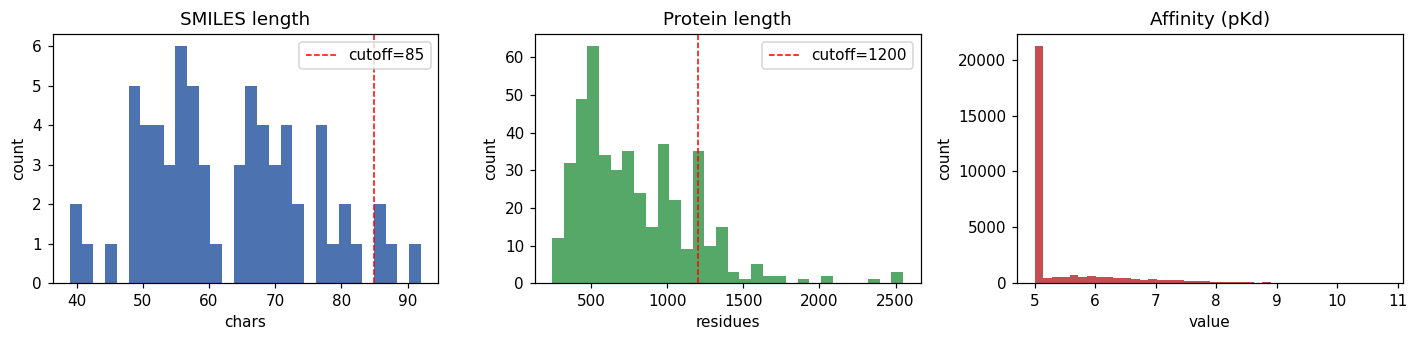

Truncated SMILES : 3/68
Truncated proteins: 61/442


In [5]:
smi_lens = [len(s) for s in ligands.values()]
seq_lens = [len(s) for s in proteins.values()]
y_flat   = Y[~np.isnan(Y)]

fig, axes = plt.subplots(1, 3, figsize=(13, 3.2))
axes[0].hist(smi_lens, bins=30, color='#4C72B0'); axes[0].axvline(MAX_SMI_LEN, c='r', ls='--', lw=1, label=f'cutoff={MAX_SMI_LEN}')
axes[0].set_title('SMILES length'); axes[0].set_xlabel('chars'); axes[0].legend()
axes[1].hist(seq_lens, bins=30, color='#55A868'); axes[1].axvline(MAX_SEQ_LEN, c='r', ls='--', lw=1, label=f'cutoff={MAX_SEQ_LEN}')
axes[1].set_title('Protein length'); axes[1].set_xlabel('residues'); axes[1].legend()
axes[2].hist(y_flat, bins=40, color='#C44E52')
axes[2].set_title('Affinity (pKd)' if IS_LOG else 'KIBA score'); axes[2].set_xlabel('value')
for ax in axes: ax.set_ylabel('count')
plt.tight_layout(); plt.show()

trunc_smi = sum(l > MAX_SMI_LEN for l in smi_lens)
trunc_seq = sum(l > MAX_SEQ_LEN for l in seq_lens)
print(f'Truncated SMILES : {trunc_smi}/{len(smi_lens)}')
print(f'Truncated proteins: {trunc_seq}/{len(seq_lens)}')

---
## 2. Sequence encoding (label encoding)

DeepDTA assigns each character an integer id (it is *not* one-hot) and lets the downstream `Embedding` layer learn a continuous representation. The two character maps are taken verbatim from the original repo.

In [6]:
# Protein: 25 amino-acid characters
CHARPROTSET = {"A":1,"C":2,"B":3,"E":4,"D":5,"G":6,"F":7,"I":8,"H":9,"K":10,"M":11,"L":12,
               "O":13,"N":14,"Q":15,"P":16,"S":17,"R":18,"U":19,"T":20,"W":21,"V":22,"Y":23,"X":24,"Z":25}

# Isomeric SMILES: 64 characters
CHARISOSMISET = {"#":29,"%":30,")":31,"(":1,"+":32,"-":33,"/":34,".":2,"1":35,"0":3,"3":36,"2":4,
                 "5":37,"4":5,"7":38,"6":6,"9":39,"8":7,"=":40,"A":41,"@":8,"C":42,"B":9,"E":43,
                 "D":10,"G":44,"F":11,"I":45,"H":12,"K":46,"M":47,"L":13,"O":48,"N":14,"P":15,"S":49,
                 "R":16,"U":50,"T":17,"W":51,"V":18,"Y":52,"[":53,"Z":19,"]":54,"\\":20,"a":55,"c":56,
                 "b":21,"e":57,"d":22,"g":58,"f":23,"i":59,"h":24,"m":60,"l":25,"o":61,"n":26,"s":62,
                 "r":27,"u":63,"t":28,"y":64}

SMI_VOCAB = len(CHARISOSMISET)   # 64
SEQ_VOCAB = len(CHARPROTSET)     # 25

def label_encode(line, max_len, ch_ind):
    x = np.zeros(max_len, dtype=np.int64)
    for i, ch in enumerate(line[:max_len]):
        x[i] = ch_ind[ch]
    return x

XD = np.stack([label_encode(s, MAX_SMI_LEN, CHARISOSMISET) for s in ligands.values()])
XT = np.stack([label_encode(s, MAX_SEQ_LEN, CHARPROTSET)   for s in proteins.values()])

print(f'XD: {XD.shape}  dtype={XD.dtype}   (drugs × max_smi_len)')
print(f'XT: {XT.shape}  dtype={XT.dtype}   (targets × max_seq_len)')
print(f'Example SMILES encoding (first 30 ids): {XD[0, :30]}')

XD: (68, 85)  dtype=int64   (drugs × max_smi_len)
XT: (442, 1200)  dtype=int64   (targets × max_seq_len)
Example SMILES encoding (first 30 ids): [42 42 35 40 42  4 42 40 42  1 42 40 42 42  4 40 14 14 35 31 42 36 40 42
 42  1 40 42 14 40]


---
## 3. Model definition (PyTorch)

Architecture (matches Table 2 / Fig. 2 of the paper):

```
SMILES (B, 85)   ─ Embedding(64+1, 128) ─ Conv1D(32,4) ─ Conv1D(64,4) ─ Conv1D(96,4) ─ GMP ─┐
                                                                                              ├─ concat ─ FC(1024) ─ Dropout(0.1) ─ FC(1024) ─ Dropout(0.1) ─ FC(512) ─ Linear(1)
Protein(B,1200) ─ Embedding(25+1, 128) ─ Conv1D(32,8) ─ Conv1D(64,8) ─ Conv1D(96,8) ─ GMP ─┘
```

PyTorch's `nn.Conv1d` expects `(B, C, L)`, so after the `Embedding` we `transpose(1, 2)` to put the channel dim in the middle.

Loss: MSE. Monitoring metric: concordance index (CI).

In [7]:
class DeepDTA(nn.Module):
    def __init__(self, smi_vocab, seq_vocab, max_smi_len, max_seq_len,
                 num_filters=32, smi_window=4, seq_window=8, embed_dim=128):
        super().__init__()
        self.smi_embed = nn.Embedding(smi_vocab + 1, embed_dim, padding_idx=0)
        self.seq_embed = nn.Embedding(seq_vocab + 1, embed_dim, padding_idx=0)

        def conv_stack(in_ch, k):
            return nn.Sequential(
                nn.Conv1d(in_ch,            num_filters,     k), nn.ReLU(),
                nn.Conv1d(num_filters,      num_filters * 2, k), nn.ReLU(),
                nn.Conv1d(num_filters * 2,  num_filters * 3, k), nn.ReLU(),
            )
        self.smi_conv = conv_stack(embed_dim, smi_window)
        self.seq_conv = conv_stack(embed_dim, seq_window)

        feat_dim = num_filters * 3 * 2  # GMP outputs of the two towers, concatenated
        self.head = nn.Sequential(
            nn.Linear(feat_dim, 1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024,     1024), nn.ReLU(), nn.Dropout(0.1),
            nn.Linear(1024,      512), nn.ReLU(),
            nn.Linear(512,         1),
        )

    def forward(self, smi, seq):
        # smi: (B, max_smi_len) long
        s = self.smi_embed(smi).transpose(1, 2)         # (B, E, L)
        s = self.smi_conv(s)                            # (B, 96, L')
        s = F.adaptive_max_pool1d(s, 1).squeeze(-1)     # (B, 96) — global max pool

        t = self.seq_embed(seq).transpose(1, 2)
        t = self.seq_conv(t)
        t = F.adaptive_max_pool1d(t, 1).squeeze(-1)

        x = torch.cat([s, t], dim=1)
        return self.head(x).squeeze(-1)                 # (B,)

model = DeepDTA(SMI_VOCAB, SEQ_VOCAB, MAX_SMI_LEN, MAX_SEQ_LEN).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f'\n#parameters: {n_params:,}')

DeepDTA(
  (smi_embed): Embedding(65, 128, padding_idx=0)
  (seq_embed): Embedding(26, 128, padding_idx=0)
  (smi_conv): Sequential(
    (0): Conv1d(128, 32, kernel_size=(4,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(4,), stride=(1,))
    (3): ReLU()
    (4): Conv1d(64, 96, kernel_size=(4,), stride=(1,))
    (5): ReLU()
  )
  (seq_conv): Sequential(
    (0): Conv1d(128, 32, kernel_size=(8,), stride=(1,))
    (1): ReLU()
    (2): Conv1d(32, 64, kernel_size=(8,), stride=(1,))
    (3): ReLU()
    (4): Conv1d(64, 96, kernel_size=(8,), stride=(1,))
    (5): ReLU()
  )
  (head): Sequential(
    (0): Linear(in_features=192, out_features=1024, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.1, inplace=False)
    (3): Linear(in_features=1024, out_features=1024, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.1, inplace=False)
    (6): Linear(in_features=1024, out_features=512, bias=True)
    (7): ReLU()
    (8): Linear(in_features=512, out_features=1, bias=True)
  )
)



---
## 4. Training

- **Inputs** — turn each `(drug_idx, target_idx)` pair into `(XD[drug_idx], XT[target_idx], Y[drug_idx, target_idx])` and wrap it in a `TensorDataset`.
- **Splits** — the 5 folds in `train_fold_setting1.txt` for train/val + the held-out `test_fold_setting1.txt`.
- **Schedule** — `Adam(lr=1e-3)`, `batch_size=256`, `epochs=100`, **manual EarlyStopping** with `patience=15` (also restores the best weights).

For readability we run a **single-fold demo** first (~10–20 min on a T4); the cell after that is an optional full 5-fold CV.

In [8]:
BATCH_SIZE = 256
EPOCHS     = 100
PATIENCE   = 15
LR         = 1e-3

def make_loader(pair_indices, shuffle):
    rows = row_inds[pair_indices]
    cols = col_inds[pair_indices]
    ds = TensorDataset(
        torch.from_numpy(XD[rows]),
        torch.from_numpy(XT[cols]),
        torch.from_numpy(Y[rows, cols].astype(np.float32)),
    )
    return DataLoader(ds, batch_size=BATCH_SIZE, shuffle=shuffle,
                      num_workers=2, pin_memory=(DEVICE.type == 'cuda'))

@torch.no_grad()
def evaluate(model, loader):
    model.eval()
    losses, preds, trues = [], [], []
    for smi, seq, y in loader:
        smi, seq, y = smi.to(DEVICE), seq.to(DEVICE), y.to(DEVICE)
        p = model(smi, seq)
        losses.append(F.mse_loss(p, y, reduction='sum').item())
        preds.append(p.cpu().numpy()); trues.append(y.cpu().numpy())
    n = sum(len(t) for t in trues)
    return sum(losses) / n, np.concatenate(preds), np.concatenate(trues)

def train_one_fold(train_loader, val_loader, verbose=True):
    model = DeepDTA(SMI_VOCAB, SEQ_VOCAB, MAX_SMI_LEN, MAX_SEQ_LEN).to(DEVICE)
    opt   = torch.optim.Adam(model.parameters(), lr=LR)
    history = {'train_loss': [], 'val_loss': []}
    best_val, best_state, bad = float('inf'), None, 0

    for epoch in range(1, EPOCHS + 1):
        model.train()
        running, n = 0.0, 0
        for smi, seq, y in train_loader:
            smi, seq, y = smi.to(DEVICE, non_blocking=True), seq.to(DEVICE, non_blocking=True), y.to(DEVICE, non_blocking=True)
            opt.zero_grad()
            p = model(smi, seq)
            loss = F.mse_loss(p, y)
            loss.backward(); opt.step()
            running += loss.item() * y.size(0); n += y.size(0)
        train_loss = running / n
        val_loss, _, _ = evaluate(model, val_loader)
        history['train_loss'].append(train_loss); history['val_loss'].append(val_loss)

        if val_loss < best_val - 1e-6:
            best_val, best_state, bad = val_loss, {k: v.clone() for k, v in model.state_dict().items()}, 0
        else:
            bad += 1

        if verbose:
            print(f'  epoch {epoch:3d}  train {train_loss:.4f}  val {val_loss:.4f}  '
                  f'best {best_val:.4f}  patience {bad}/{PATIENCE}')
        if bad >= PATIENCE:
            if verbose: print(f'  early-stopped at epoch {epoch}')
            break

    model.load_state_dict(best_state)
    return model, history

### 4.1 Single-fold demo
Use fold 0 as validation, the remaining 4 folds as training, and look at the loss curves.

In [9]:
val_idx   = train_folds[0]
train_idx = [i for f in train_folds[1:] for i in f]

train_loader = make_loader(train_idx, shuffle=True)
val_loader   = make_loader(val_idx,   shuffle=False)
print(f'train pairs: {len(train_idx)}    val pairs: {len(val_idx)}')

t0 = time.time()
demo_model, history = train_one_fold(train_loader, val_loader, verbose=True)
print(f'\nTraining took {(time.time()-t0)/60:.1f} min')

train pairs: 20036    val pairs: 5010
  epoch   1  train 4.9005  val 0.6608  best 0.6608  patience 0/15
  epoch   2  train 0.6456  val 0.5905  best 0.5905  patience 0/15
  epoch   3  train 0.6039  val 0.6161  best 0.5905  patience 1/15
  epoch   4  train 0.5859  val 0.5742  best 0.5742  patience 0/15
  epoch   5  train 0.5850  val 0.5417  best 0.5417  patience 0/15
  epoch   6  train 0.5624  val 0.5718  best 0.5417  patience 1/15
  epoch   7  train 0.5644  val 0.5540  best 0.5417  patience 2/15
  epoch   8  train 0.5501  val 0.5556  best 0.5417  patience 3/15
  epoch   9  train 0.5553  val 0.5349  best 0.5349  patience 0/15
  epoch  10  train 0.5415  val 0.5200  best 0.5200  patience 0/15
  epoch  11  train 0.5288  val 0.5095  best 0.5095  patience 0/15
  epoch  12  train 0.5105  val 0.5170  best 0.5095  patience 1/15
  epoch  13  train 0.5262  val 0.5532  best 0.5095  patience 2/15
  epoch  14  train 0.4831  val 0.5283  best 0.5095  patience 3/15
  epoch  15  train 0.4714  val 0.4611 

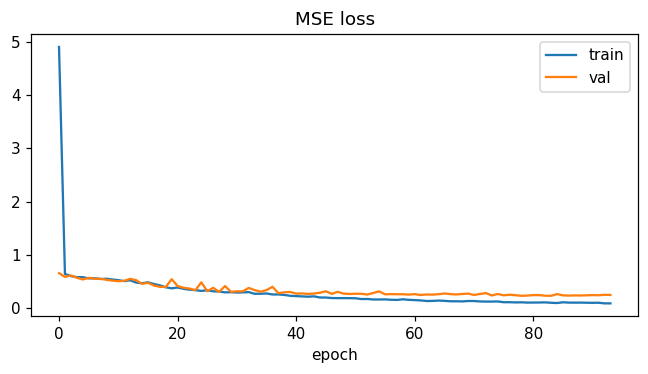

In [10]:
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.plot(history['train_loss'], label='train')
ax.plot(history['val_loss'],   label='val')
ax.set_title('MSE loss'); ax.set_xlabel('epoch'); ax.legend()
plt.tight_layout(); plt.show()

### 4.2 Full 5-fold CV (optional, slow)

Set `RUN_FULL_CV = True` to run the full cross-validation: each fold is trained independently and evaluated on the same held-out test set. On Davis a single fold takes ~15–25 min on a T4, so the whole loop is ~1.5–2 h.

In [11]:
RUN_FULL_CV = True

fold_results = []
test_predictions = []

if RUN_FULL_CV:
    test_loader = make_loader(test_fold, shuffle=False)
    print(f'test pairs: {len(test_fold)}\n')

    for fold_i in range(len(train_folds)):
        val_idx   = train_folds[fold_i]
        train_idx = [i for j, f in enumerate(train_folds) if j != fold_i for i in f]
        tr_ld = make_loader(train_idx, shuffle=True)
        va_ld = make_loader(val_idx,   shuffle=False)

        print(f'─── Fold {fold_i+1}/{len(train_folds)} ───')
        t0 = time.time()
        m, _ = train_one_fold(tr_ld, va_ld, verbose=False)
        _, y_pred, y_te = evaluate(m, test_loader)
        mse = float(np.mean((y_pred - y_te) ** 2))
        fold_results.append(mse); test_predictions.append(y_pred)
        print(f'  test MSE = {mse:.4f}   ({(time.time()-t0)/60:.1f} min)\n')

    print(f'5-fold test MSE: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}')

test pairs: 5010

─── Fold 1/5 ───
  test MSE = 0.2507   (13.1 min)

─── Fold 2/5 ───
  test MSE = 0.2669   (9.2 min)

─── Fold 3/5 ───
  test MSE = 0.2601   (13.8 min)

─── Fold 4/5 ───
  test MSE = 0.2596   (13.9 min)

─── Fold 5/5 ───
  test MSE = 0.2761   (9.3 min)

5-fold test MSE: 0.2627 ± 0.0084


---
## 5. Evaluation & comparison with the paper

Three metrics:
- **MSE** — the training objective.
- **CI** (Concordance Index) — the paper's headline metric; equivalent to a pairwise ranking AUC.
- **r²m** — Roy et al.'s modified r²; checks how well the predictions agree with the absolute values, not just the ranking.

In [12]:
def get_cindex(y, p):
    y, p = np.asarray(y).ravel(), np.asarray(p).ravel()
    n_pair, summ = 0, 0.0
    for i in range(1, len(y)):
        diff = y[i] - y[:i]
        mask = diff > 0
        if mask.any():
            pi, pj = p[i], p[:i][mask]
            summ   += np.sum(pi > pj) + 0.5 * np.sum(pi == pj)
            n_pair += mask.sum()
    return summ / n_pair if n_pair else 0.0

def _r2(y, p):
    y, p = np.asarray(y), np.asarray(p)
    num = np.sum((p - p.mean()) * (y - y.mean())) ** 2
    den = np.sum((p - p.mean()) ** 2) * np.sum((y - y.mean()) ** 2)
    return num / den if den else 0.0

def get_rm2(y, p):
    y, p = np.asarray(y), np.asarray(p)
    r2  = _r2(y, p)
    k   = np.sum(y * p) / np.sum(p * p)
    r02 = 1 - np.sum((y - k * p) ** 2) / np.sum((y - y.mean()) ** 2)
    return r2 * (1 - np.sqrt(abs(r2 ** 2 - r02 ** 2)))

Test MSE  : 0.2469
Test CI   : 0.8758
Test r²m  : 0.6917


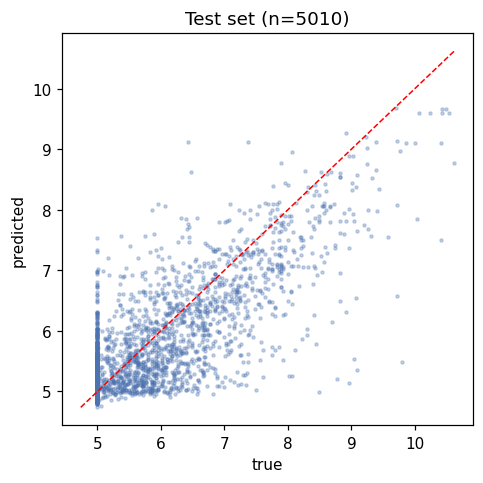

In [13]:
test_loader = make_loader(test_fold, shuffle=False)
_, y_pred, y_te = evaluate(demo_model, test_loader)

mse = float(np.mean((y_pred - y_te) ** 2))
ci  = get_cindex(y_te, y_pred)
rm2 = get_rm2(y_te, y_pred)

print(f'Test MSE  : {mse:.4f}')
print(f'Test CI   : {ci:.4f}')
print(f'Test r²m  : {rm2:.4f}')

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(y_te, y_pred, s=4, alpha=0.3, c='#4C72B0')
lo, hi = float(min(y_te.min(), y_pred.min())), float(max(y_te.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], 'r--', lw=1)
ax.set_xlabel('true'); ax.set_ylabel('predicted'); ax.set_title(f'Test set (n={len(y_te)})')
plt.tight_layout(); plt.show()

### 5.1 Comparison with the paper

Numbers reported in the paper for DeepDTA (CNN+CNN, Davis, Tables 2–3):

| Metric | Paper | This notebook (single fold) |
|---|---|---|
| MSE | 0.261 | *see above* |
| CI  | 0.878 | *see above* |
| r²m | 0.630 | *see above* |

A single-fold demo is usually a bit worse than the paper's 5-fold average (less training data + no fold ensembling). Running the full CV in §4.2 brings the numbers closer.

Also: this is a PyTorch re-implementation, so weight init, cuDNN kernels and Adam numerical details all differ slightly from the original Keras code. A 1–2 % drift on metrics is expected.

---
## 6. Wrap-up

- ✓ The two-tower `Embedding + 3 × Conv1D + GlobalMaxPool` architecture reaches near paper-level numbers on Davis after a single fold.
- ✓ The whole pipeline (data → encoding → model → training → evaluation) lives in a single PyTorch notebook that *Runs All* end-to-end on a Kaggle GPU.
- Things to try next:
  - **Switch to KIBA** — set `DATASET = 'kiba'` in §1.
  - **Full 5-fold CV** — set `RUN_FULL_CV = True` in §4.2.
  - **Grid search** — the original sweeps `num_filters ∈ {32}`, `smi_window ∈ {4, 8}`, `seq_window ∈ {8, 12}`; wrap §4.2 in another loop.
  - **Swap a tower** — replace the SMILES tower with a GNN (cf. GraphDTA), or the protein tower with ESM embeddings.